# Ejercicio 1
Implemente un perceptrón simple que aprenda la función lógica AND y la función
lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el
entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos
los vectores de entrada de la red.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=100):
        self.weights = np.zeros(input_size + 1)  # +1 para el bias
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors = []

    def predict(self, X):
        h = np.dot(X, self.weights[1:]) + self.weights[0]  # w0 es el bias
        return np.where(h >= 0, 1, -1)

    def train(self, X, y):
        for _ in range(self.epochs):
            E = 0
            for xi, target in zip(X, y):
                y_pred = self.predict(xi)
                error = target - y_pred
                self.weights[1:] += self.learning_rate * error * xi
                self.weights[0] += self.learning_rate * error  # Ajuste del bias
                E += error**2
            self.errors.append(E)
            if E == 0:  # Si no hay errores, detener el entrenamiento
                break
        return E

           
    def plot_decision_boundary(self, X, y):
        # Definir los valores de x1
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        x1_vals = np.linspace(x1_min, x1_max, 100)

        # Ecuación de la recta: w0 + w1 * x1 + w2 * x2 = 0 => x2 = -(w0 + w1 * x1) / w2
        x2_vals = -(self.weights[0] + self.weights[1] * x1_vals) / self.weights[2]

        # Gráfico de los puntos y la recta
        plt.plot(x1_vals, x2_vals, 'b-', label='Recta discriminadora')
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', marker='o', label='Clase 1')
        plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='g', marker='x', label='Clase -1')

        plt.xlim([x1_min, x1_max])
        plt.ylim([x2_min, x2_max])
        plt.xlabel(r'$x_1$')
        plt.ylabel(r'$x_2$')
        plt.legend()
        plt.title('Recta discriminadora y puntos')
        plt.grid(True)
        plt.show()

    # Grafico la evolución del error
    def plot_error(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.errors)
        plt.xlabel('Época')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el entrenamiento')
        plt.grid(True)
        plt.show()

### Caso compuerta AND

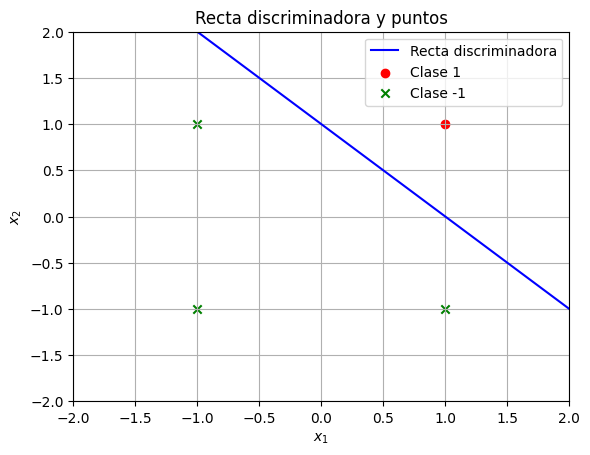

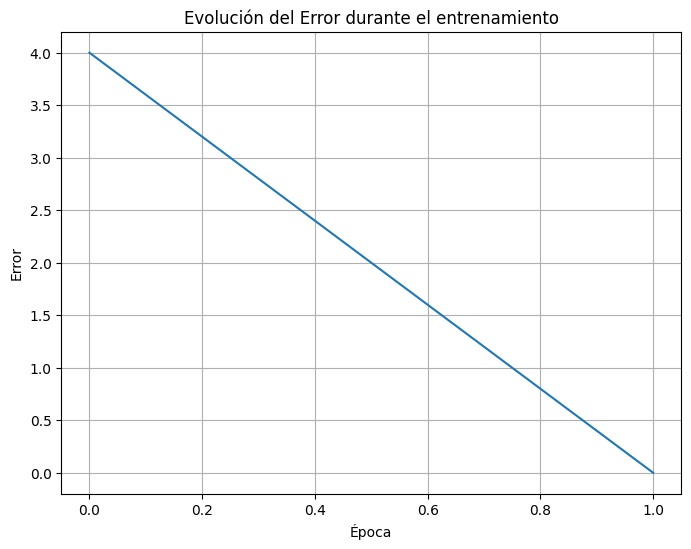

In [2]:
# Datos para la función AND
X_and = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

# Entrenar para la función AND
perceptron_and = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_and.train(X_and, y_and)
perceptron_and.plot_decision_boundary(X_and, y_and)
perceptron_and.plot_error()

### Caso compuerta OR

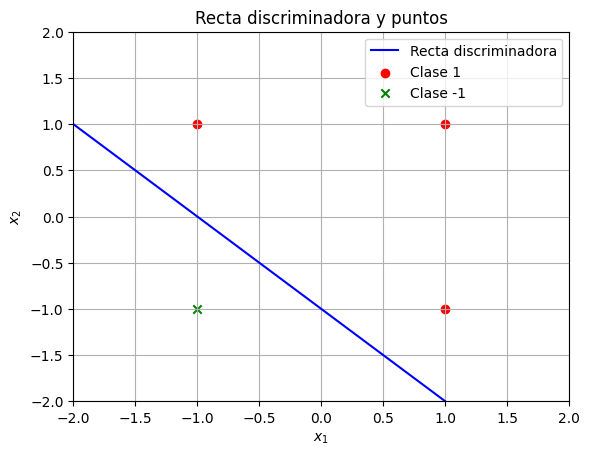

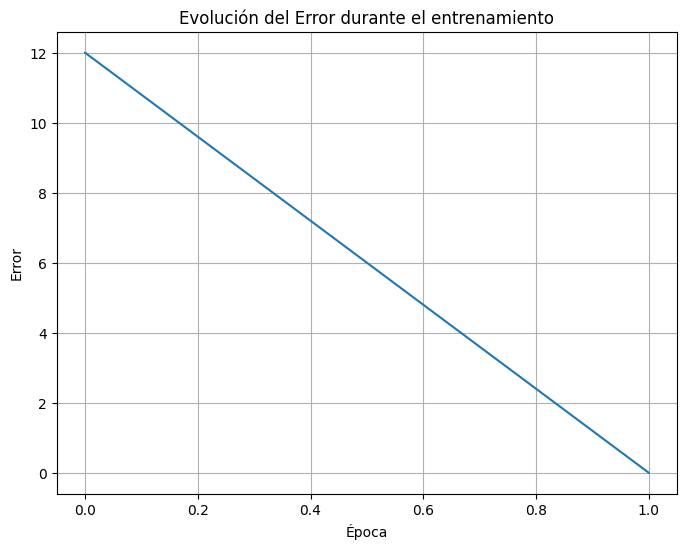

In [3]:
# Datos para la función OR
X_or = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_or = np.array([-1, 1, 1, 1])

# Entrenar para la función OR
perceptron_or = Perceptron(2,learning_rate=0.1, epochs=100)
perceptron_or.train(X_or, y_or)
perceptron_or.plot_decision_boundary(X_or, y_or)
perceptron_or.plot_error()

-------------------------------------------------------------------------
# Ejercicio 2

Determine numéricamente cómo varía la capacidad del perceptrón simple en función
del número de patrones enseñados.

$$ N : \text{Cantidad de features o dimension del espacio de patrones} \quad \wedge \quad N_p : \text{Cantidad de patrones a enseñar}  $$


$$ C (N,N_p) = \frac{\text{\# Problemas linealmente separables}}{ \text{ \# Problemas Totales}} $$

Proceso para estimar de forma numerica la capacidad del perceptron simple en funcion del numero de patrones ensenados para N fijo:

1) Generar $N_p$ patrones: $\vec{X}_n (i) \sim \mathcal{U}(-1,1) $ y $ Y_n \sim \mathcal{B}(p=\frac{1}{2}) $
2) Entrenar el perceptron
3) Si el perceptron aprendel el problema: $N_p \longleftarrow N_p + 1 $ 

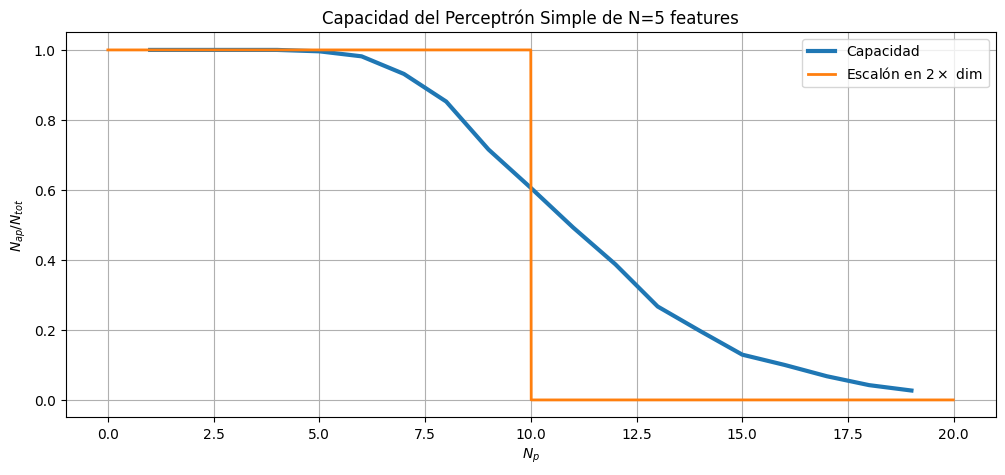

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Dimensión del espacio de patrones (número de características)
N = 5


# Vector de número de patrones (Np) a probar
Np_vec = np.arange(1, N * 4, 1)

# Inicialización del vector de capacidad
Capacidad_vec = np.zeros(Np_vec.shape)

# Iterar sobre diferentes valores de Np
for i, Np in enumerate(Np_vec):
    # Total de problemas a presentar (100 * Np)
    problemas_Np = 100 * Np
    
    # Contador de problemas aprendidos correctamente
    Nap = 0
    
    # Generar y evaluar cada problema
    for _ in range(problemas_Np):
        # Patrones de entrada aleatorios y salidas Y en {-1, 1}
        patterns = 2 * np.random.uniform(size=(Np, N)) - 1
        Y = 2 * np.random.binomial(n=1, p=1/2, size=Np) - 1
        
        # Crear y entrenar el perceptrón
        perceptron = Perceptron(input_size=N, learning_rate=0.1, epochs=50)
        error = perceptron.train(patterns, Y)
        
        # Contar si el problema se aprendió sin error
        if error == 0:
            Nap += 1
    
    # Calcular la capacidad de aprendizaje
    Capacidad_vec[i] = Nap / problemas_Np

# Graficar los resultados obtenidos para N=dim
plt.figure(figsize=(12, 5))

# Capacidad estimada del perceptrón
plt.plot(Np_vec, Capacidad_vec, linewidth=3, label='Capacidad')

# Escalón negativo centrado en 2*dim
x = np.arange(0, 4 * N, 0.01)
y = x <= 2 * N
plt.plot(x, y, linewidth=2, label='Escalón en $2 \\times$ dim')

# Configuración del gráfico
plt.title('Capacidad del Perceptrón Simple de N={} features'.format(N))
plt.xlabel('$N_p$')
plt.ylabel('$N_{ap}/N_{tot}$')
plt.legend()
plt.grid()
plt.show()


-------------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 3

Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4
entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre
cómo evoluciona el error durante el entrenamiento.


### Representacion Matricial de la Red (XOR: 2 entradas)
Muestro como se realizaran las cuentas matriciales para un perceptron multicapa de 2 entradas + sesgo, 3 neuronas en capa oculta y 1 neurona de salida


#### Capa de Entrada
La capa de entrada tendra 2 entradas y como se entrenara con 4 patrones, la matriz de entrada sera de $\textbf{3x4}$, la primera fila son 1s que representaran el sesgo, siendo asi la matriz de entrada $\textbf{X}$ :
$$ X =  
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
$$
Cada columna es un patrón y cada fila es la entrada a cada entrada de la capa de entrada. 


#### Capa Oculta
Para el caso de la XOR de 2 entradas, el caso minimo con el que se logra aprenderla es con 3 neuronas de capa oculta. Supongamos 3 neuronas de capa oculta (filas), entonces la matriz de
pesos sinapticos entre la capa de entrada y la capa oculta es $W_{input} \in \mathbb{R}^{3 \times 2}$
$$
W_{input} =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
$$
Donde $w_{j0}$ corresponde al peso sinaptico del sesgo de la neurona j


#### Capa Salida 
Dado que se tiene una sola salida y la capa oculta solo tiene 3 neuronas, la matriz de pesos sinapticos entre la capa oculta y la capa de salida es $W_{output} \in \mathbb{R}^{1 \times 3}$ :
$$
W_{output} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
$$



### Fordward Propagation
Partimos desde la capa de entrada, obtengo que la entrada neta a la capa oculta es:

$$
H_{input} = W_{input} * X =
\begin{bmatrix}
w_{10} & w_{11} & w_{12} \\
w_{20} & w_{21} & w_{22} \\
w_{30} & w_{31} & w_{32}
\end{bmatrix}
*
\begin{bmatrix}
1 & 1 & 1 & 1 \\
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24}
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13} & h_{14} \\
h_{21} & h_{22} & h_{23} & h_{24} \\
h_{31} & h_{32} & h_{33} & h_{34}
\end{bmatrix}

$$

Luego, pasando por la funcion de activación $\textbf{g(x)}$ obtengo que: 
$$X_{input} = g(H_{input}) = \begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}$$

Luego se parte de la entrada neta a la capa de salida :
$$
H_{output} = W_{output} * X_{input} =
\begin{bmatrix}
w_{out1} & w_{out2} & w_{out3}
\end{bmatrix}
*
\begin{bmatrix}
x_{11} & x_{12} & x_{13} & x_{14} \\
x_{21} & x_{22} & x_{23} & x_{24} \\
x_{31} & x_{32} & x_{33} & x_{34}
\end{bmatrix}
=
\begin{bmatrix}
h_{1} & h_{2} & h_{3} & h_{4} \\
\end{bmatrix}
$$


Finalmente la salida $y$ es:
$$
y = g(H_{output}) = \begin{bmatrix}
y_{1} & y_{2} & y_{3} & y_{4} \\
\end{bmatrix}
$$

### Backward Propagation
El primer delta a calcular es :
$$
\begin{align*}
\delta_{output} = g'(H_{output}) \cdot (y_d - y) & = \begin{bmatrix}
g'(h_{1}) & g'(h_{2}) & g'(h_{3}) & g'(h_{4}) \\
\end{bmatrix}
\cdot
\begin{bmatrix}
y_d(1) - y_{1} & y_d(2) - y_{2} & y_d(3) - y_{3} & y_d(4) - y_{4} \\
\end{bmatrix} \\
& =
\begin{bmatrix}
g'(h_{1})(y_d(1) - y_{1}) & g'(h_{2})(y_d(2) - y_{2}) & g'(h_{3})(y_d(3) - y_{3}) & g'(h_{4})(y_d(4) - y_{4}) \\
\end{bmatrix}
\end{align*}
$$

Luego:
$$
\delta_{hidden} = g'(H_{input}) \cdot (W_{output} * \delta_{output}^T)
$$

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Clase para una capa de la red neuronal
class Layer:
    def __init__(self, input_size, output_size, activation_function, activation_derivative):
        # Inicialización de pesos y sesgos
        self.weights = np.random.randn(input_size, output_size) * 0.1
        self.biases = np.zeros((1, output_size))
        self.activation_function = activation_function
        self.activation_derivative = activation_derivative

    def forward(self, x):
        # Propagación hacia adelante
        self.input_data = x
        self.h = np.dot(x, self.weights) + self.biases
        self.output = self.activation_function(self.h)
        return self.output

    def backward(self, output_error, learning_rate):
        # Retropropagación del error
        delta = output_error * self.activation_derivative(self.h)
        input_error = np.dot(delta, self.weights.T)
        
        # Actualización de los pesos y sesgos
        self.weights -= learning_rate * np.dot(self.input_data.T, delta)
        self.biases -= learning_rate * np.sum(delta, axis=0, keepdims=True)
        
        return input_error

# Funciones de activación (tangente hiperbólica)
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# Agrega una función de activación lineal
def linear(x):
    return x

def linear_derivative(x):
    # La derivada de una función lineal es 1
    return np.ones_like(x)


# Clase para el perceptrón multicapa
class MultilayerPerceptron:
    def __init__(self, layer_sizes, activation_function, activation_derivative, learning_rate=0.1, isLinearOut = False):
        self.errors_train = []
        self.errors_test = []
        self.errors = []
        self.layers = []
        self.learning_rate = learning_rate
        for i in range(len(layer_sizes) - 1):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i + 1], activation_function, activation_derivative))
        # Cambia la función de activación de la última capa a lineal
        if(isLinearOut) :
            self.layers[-1].activation_function = linear
            self.layers[-1].activation_derivative = linear_derivative


    def forward(self, X):
        # Propagación hacia adelante a través de todas las capas
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, X, y):
        # Cálculo del error y retropropagación
        output_error = self.layers[-1].output - y
        for layer in reversed(self.layers):
            output_error = layer.backward(output_error, self.learning_rate)

    def train(self, X, y, epochs):
        # Entrenamiento con actualización en batch
        for _ in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calcular el error
            error = np.mean(np.square(output - y))  # Error cuadrático medio
            self.errors.append(error)

            # Backward pass
            self.backward(X, y)


    def plot_error_xor(self):
        # Mostrar evolución del error
        plt.plot(self.errors)
        plt.xlabel('Epoch')
        plt.ylabel('Error')
        plt.title('Evolución del Error durante el Entrenamiento')
        plt.show()

    def evaluate(self, X, y):
        # Evaluar el rendimiento de la red
        output = self.forward(X)
        for i in range(len(y)):
            print(f"Resultado de la red neuronal: {output[i]} y resultado: {y[i]}")

    def train_minibatch(self, X_train, y_train, X_test, y_test, epochs, batch_size=1):
        n_samples = X_train.shape[0]
        for epoch in range(epochs):
            # Embarajar los datos de entrenamiento
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_train = X_train[indices]
            y_train = y_train[indices]

            for start_idx in range(0, n_samples, batch_size):
                end_idx = start_idx + batch_size
                X_batch = X_train[start_idx:end_idx]
                y_batch = y_train[start_idx:end_idx]

                # Forward pass y retropropagación por minibatch
                output = self.forward(X_batch)
                batch_error = np.mean(np.square(output - y_batch))
                self.errors_train.append(batch_error)
                self.backward(X_batch, y_batch)

            # Calcular error en el set de testeo al final de cada época
            test_output = self.forward(X_test)
            epoch_test_error = np.mean(np.square(test_output - y_test))
            self.errors_test.append(epoch_test_error)

    def plot_errors_function(self):
        # Gráfico de error de entrenamiento por minibatch
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.errors_train, label='Error de entrenamiento por minibatch')
        plt.xlabel('Iteración (minibatch)')
        plt.ylabel('Error')
        plt.title('Error de Entrenamiento por Minibatch')

        # Gráfico de error de testeo por época
        plt.subplot(1, 2, 2)
        plt.plot(self.errors_test, label='Error de testeo por época', color='orange')
        plt.xlabel('Época')
        plt.ylabel('Error')
        plt.title('Error de Testeo por Época')

        plt.tight_layout()
        plt.show()

    def plot_scatter(self, X, y):
        output = self.forward(X)
        plt.scatter(y, output, color='blue', alpha=0.5)
        plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')  # Línea de referencia ideal
        plt.xlabel('Salida deseada')
        plt.ylabel('Salida obtenida')
        plt.title('Gráfico de dispersión entre la salida deseada y obtenida')
        plt.show()


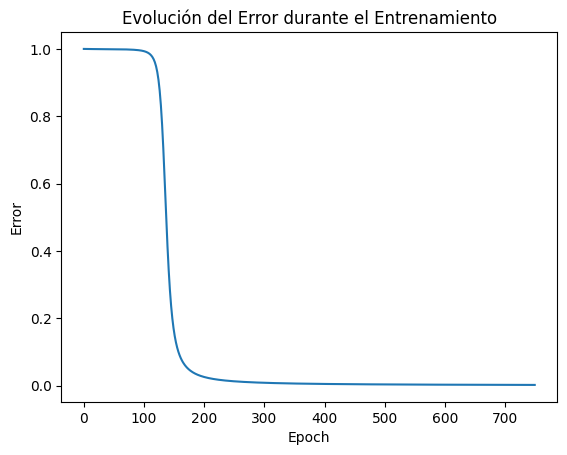


Evaluación del modelo para XOR de 2 entradas:
Resultado de la red neuronal: [-0.95111469] y resultado: [-1]
Resultado de la red neuronal: [0.96413197] y resultado: [1]
Resultado de la red neuronal: [0.96315138] y resultado: [1]
Resultado de la red neuronal: [-0.95105109] y resultado: [-1]


In [8]:
# Datos para XOR de 2 entradas con -1 y 1
X_xor2 = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
y_xor2 = np.array([[-1], [1], [1], [-1]])

# Crear el modelo para XOR de 2 entradas
mlp_2 = MultilayerPerceptron([2, 3, 1],tanh,tanh_derivative, learning_rate=0.1)
mlp_2.train(X_xor2, y_xor2, epochs=750)
mlp_2.plot_error_xor()

# Evaluación final
print("\nEvaluación del modelo para XOR de 2 entradas:")
mlp_2.evaluate(X_xor2, y_xor2)

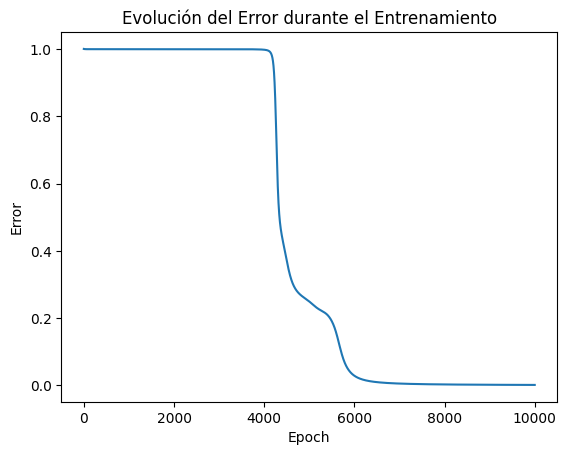


Evaluación del modelo para XOR de 4 entradas:
Resultado de la red neuronal: [-0.98621659] y resultado: [-1]
Resultado de la red neuronal: [0.97904915] y resultado: [1]
Resultado de la red neuronal: [0.94726283] y resultado: [1]
Resultado de la red neuronal: [-0.99727897] y resultado: [-1]
Resultado de la red neuronal: [0.97954081] y resultado: [1]
Resultado de la red neuronal: [-0.93887307] y resultado: [-1]
Resultado de la red neuronal: [-0.98513712] y resultado: [-1]
Resultado de la red neuronal: [0.97919476] y resultado: [1]
Resultado de la red neuronal: [0.96160895] y resultado: [1]
Resultado de la red neuronal: [-0.97219671] y resultado: [-1]
Resultado de la red neuronal: [-0.91750828] y resultado: [-1]
Resultado de la red neuronal: [0.97125807] y resultado: [1]
Resultado de la red neuronal: [-0.99461017] y resultado: [-1]
Resultado de la red neuronal: [0.96940947] y resultado: [1]
Resultado de la red neuronal: [0.9610556] y resultado: [1]
Resultado de la red neuronal: [-0.972642

In [13]:
# Datos para XOR de 4 entradas con -1 y 1
X_xor4 = np.array([[-1, -1, -1, -1], [-1, -1, -1, 1], [-1, -1, 1, -1], [-1, -1, 1, 1], 
                [-1, 1, -1, -1], [-1, 1, -1, 1], [-1, 1, 1, -1], [-1, 1, 1, 1], 
                [1, -1, -1, -1], [1, -1, -1, 1], [1, -1, 1, -1], [1, -1, 1, 1], 
                [1, 1, -1, -1], [1, 1, -1, 1], [1, 1, 1, -1], [1, 1, 1, 1]])
y_xor4 = np.array([[-1], [1], [1], [-1], [1], [-1], [-1], [1], 
                [1], [-1], [-1], [1], [-1], [1], [1], [-1]])
 

# Crear el modelo para XOR de 4 entradas
mlp_4 = MultilayerPerceptron([4, 6, 1],tanh,tanh_derivative, learning_rate=0.01)
mlp_4.train(X_xor4, y_xor4, epochs=10000)
mlp_4.plot_error_xor()

# Evaluación final
print("\nEvaluación del modelo para XOR de 4 entradas:")
mlp_4.evaluate(X_xor4, y_xor4)

-------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 4

a) Implemente una red con aprendizaje Backpropagation que aprenda la siguiente
función:
f ( x , y ,z)=sin( x )+cos( y )+z
donde: x e y ∊ [ 0 ,2 π ] y z ∊[−1,1]. Para ello construya un conjunto de datos de
entrenamiento y un conjunto de evaluación. Muestre la evolución del error de
entrenamiento y de evaluación en función de las épocas de entrenamiento.

b) Estudie la evolución de los errores durante el entrenamiento de una red con una
capa oculta de 30 neuronas cuando el conjunto de entrenamiento contiene 40
muestras. ¿Que ocurre si el minibatch tiene tamaño 40? ¿Y si tiene tamaño 1?



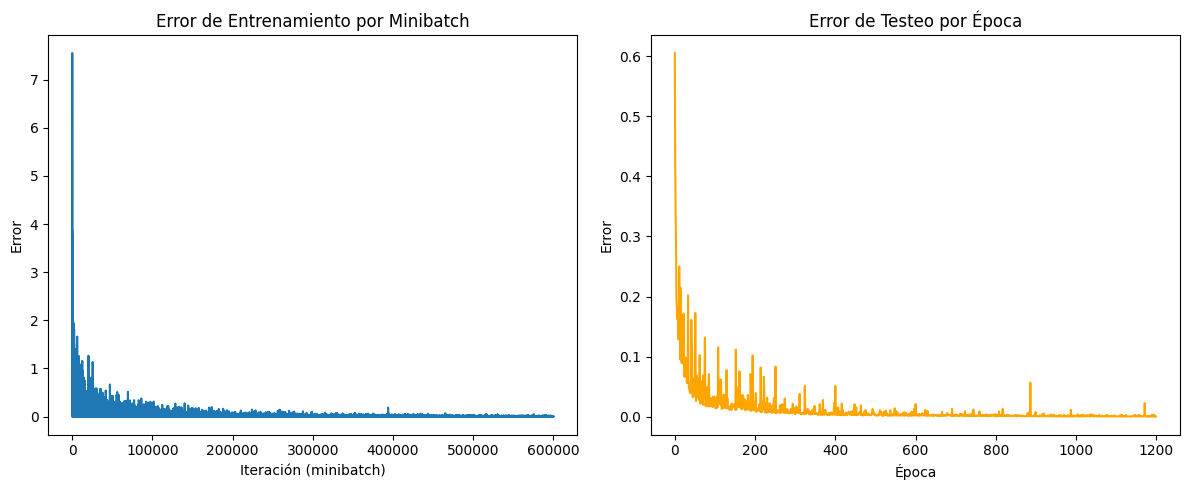

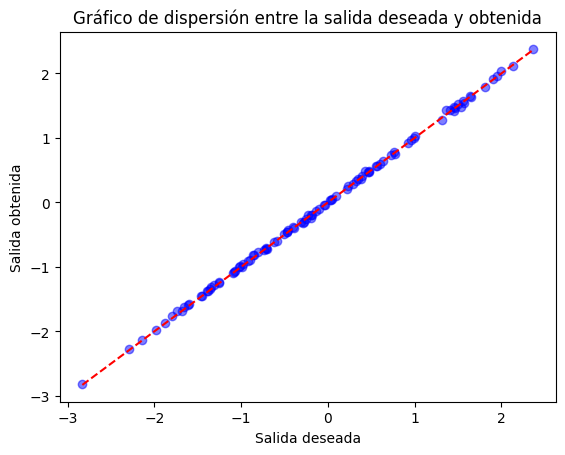

In [14]:

# Generar datos de entrenamiento y evaluación
def generate_data(n_samples):
    x = np.random.uniform(0, 2 * np.pi, n_samples)
    y = np.random.uniform(0, 2 * np.pi, n_samples)
    z = np.random.uniform(-1, 1, n_samples)
    f = np.sin(x) + np.cos(y) + z
    return np.column_stack((x, y, z)), f.reshape(-1, 1)

# Inicializar y entrenar la red
X_train, y_train = generate_data(1000)
X_test, y_test = generate_data(100)

# En la inicialización de la red, especifica la función lineal para la última capa
mlp = MultilayerPerceptron(
    layer_sizes=[3, 30, 1],
    activation_function=tanh,
    activation_derivative=tanh_derivative,
    learning_rate=0.01,
    isLinearOut= True
)

# Entrenamiento con minibatch de 1 (SGD)
mlp.train_minibatch(X_train, y_train, X_test, y_test, epochs=1200, batch_size=2)
mlp.plot_errors_function()

# Evaluar y graficar la salida obtenida vs. salida deseada en el testeo
mlp.plot_scatter(X_test, y_test)



---------------------------------------------------------------------------------------------------------------------------------------------------
# Ejercicio 5
Siguiendo el trabajo de Hinton y Salakhutdinov (2006), entrene una máquina restringida
de Boltzmann con imágenes de la base de datos MNIST. Muestre el error de
recontruccion durante el entrenamiento, y ejemplos de cada uno de los dígitos
reconstruidos.

$$
\begin{align*}
1) \ & m_i = \text{pixel}(i) \\
2) \ & v_i \sim \mathcal{N}(\mu = m_i, \sigma = 1) \\
3) \ & h_j = 1 \text{ con probabilidad } p = \sigma \left( \sum_i w_{ij} v_i + b_j \right) \text{ con } \sigma(x) = \frac{1}{1 + e^{-x}} \\
4) \ & \text{Guardo } (v_i, h_j) \text{ en set DATA} \\
5) \ & m_i = \sum_i w_{ij} h_j + b_i \\
6) \ & v_i \sim \mathcal{N}(\mu = m_i, \sigma = 1) \\
7) \ & h_j = 1 \text{ con probabilidad } p = \sigma \left( \sum_i w_{ij} v_i + b_j \right) \text{ con } \sigma(x) = \frac{1}{1 + e^{-x}} \\
8) \ & \text{Guardo } (v_i, h_j) \text{ en set RECON}
\end{align*}
$$

Repito así para todas las imágenes del set o entreno en minibatch.

Luego:

$$
\begin{align*}
\Delta w_{ij} &= \eta \left( \langle (v_i \cdot h_j) \rangle_{\text{DATA}}^M - \langle (v_i \cdot h_j) \rangle_{\text{RECON}}^M \right) \\
\Delta b_i &= \eta \left( \langle (v_i) \rangle_{\text{DATA}}^M - \langle (v_i) \rangle_{\text{RECON}}^M \right) \\
\Delta b_j &= \eta \left( \langle (h_j) \rangle_{\text{DATA}}^M - \langle (h_j) \rangle_{\text{RECON}}^M \right)
\end{align*}
$$



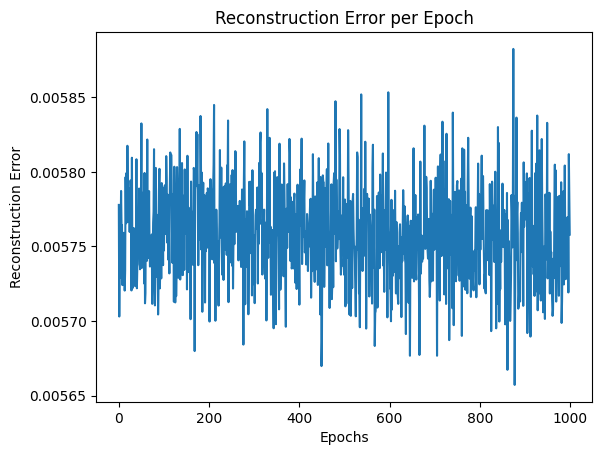

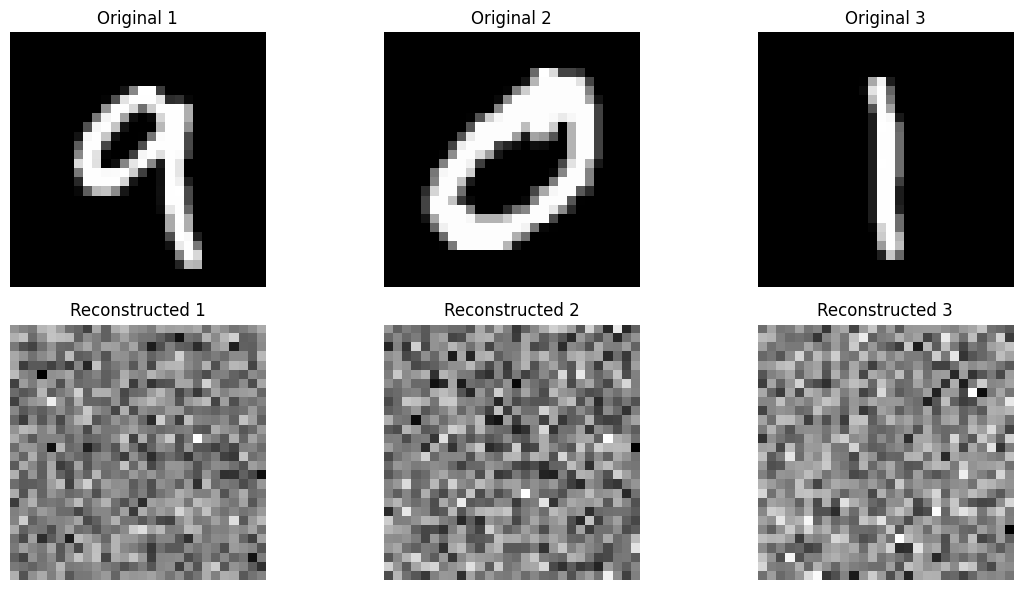

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        
        # Inicialización de los pesos y sesgos
        limit = np.sqrt(6 / (self.n_visible + self.n_hidden))
        self.weights = np.random.uniform(-limit, limit, (self.n_visible, self.n_hidden))
        self.bias_visible = np.zeros(n_visible)
        self.bias_hidden = np.zeros(n_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, input):
        # Cálculo de activación de la capa oculta
        # Crear una matriz de v_i con la misma forma que 'images_normalized'
        visible_state = np.random.normal(loc=input, scale=1, size=input.shape)
        hidden_activation = np.dot(visible_state, self.weights) + self.bias_hidden
        hidden_prob = self.sigmoid(hidden_activation)
        hidden_state = (hidden_prob > np.random.rand(self.n_hidden)).astype(np.float64)
        
        return visible_state, hidden_state
    
    def backward(self, h):
        # Reconstrucción de la capa visible
        m_i = np.dot(h, self.weights.T) + self.bias_visible
        visible_state = np.random.normal(loc=m_i, scale=1, size=m_i.shape)
        hidden_prob = self.sigmoid(np.dot(visible_state, self.weights) + self.bias_hidden)
        hidden_state = (hidden_prob > np.random.rand(self.n_hidden)).astype(np.float64)
        return visible_state, hidden_state
    

    def update_weights_and_biases(self, v_o, h_o, v_k, h_k):
        # Producto externo de las filas de visible_state con hidden_state
        positive_grad = np.dot(v_o.T, h_o)

        
        # Producto externo de las filas de visible_reconstructed con hidden_reconstructed
        negative_grad = np.dot(v_k.T, h_k)

        # Actualización de los pesos
        self.weights += self.learning_rate * (positive_grad - negative_grad) / v_o.shape[0]

        # Actualización de los sesgos
        self.bias_visible += self.learning_rate * np.mean(v_o - v_k, axis=0)
        self.bias_hidden += self.learning_rate * np.mean(h_o - h_k, axis=0)


    def train(self, train_data, epochs=10):
        errors = []  # Lista para almacenar los errores de cada época
        for epoch in range(epochs):
            total_error = 0  # Para calcular el error total de cada época
            # Asegúrate de que data esté en un formato adecuado (ej., normalizado entre 0 y 1)
            visible_state, hidden_state = self.forward(train_data)
            visible_reconstructed, hidden_reconstructed = self.backward(hidden_state)
            self.update_weights_and_biases(visible_state, hidden_state, visible_reconstructed, hidden_reconstructed)

            # Calcular el error de reconstrucción (error cuadrático medio)
            error = np.mean((train_data - visible_reconstructed) ** 2)  # Error cuadrático medio
            total_error += error

            # Guardar el error promedio de esta época
            errors.append(total_error / len(train_data))

            # Mostrar el error de reconstrucción al final de cada época
            #print(f"Epoch {epoch+1}/{epochs}, Reconstruction Error: {total_error / len(train_data)}")

        # Graficar el error de reconstrucción
        plt.plot(range(epochs), errors)
        plt.xlabel('Epochs')
        plt.ylabel('Reconstruction Error')
        plt.title('Reconstruction Error per Epoch')
        plt.show()


# Graficar 3 imágenes aleatorias de las originales y 3 de las reconstruidas
def plot_random_images(original_images, reconstructed_images, n_images=3):
    # Seleccionar 3 índices aleatorios
    random_indices = random.sample(range(original_images.shape[0]), n_images)

    plt.figure(figsize=(12, 6))

    # Graficar las imágenes originales
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, i)
        plt.imshow(original_images[idx].reshape(28, 28), cmap='gray')  # Asumo que las imágenes son 28x28
        plt.title(f'Original {i}')
        plt.axis('off')

    # Graficar las imágenes reconstruidas
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, n_images + i)
        plt.imshow(reconstructed_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Reconstructed {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Cargar el archivo .mat
mat_file_path = 'datosTrain.mat'
mat_data = scipy.io.loadmat(mat_file_path)

# Asignar los datos de entrenamiento y prueba desde el archivo .mat
train_images = mat_data['data'] 
# Normalizar las imágenes para que estén en el rango [0, 1]
train_images = train_images / 255.0


# Crear la RBM y entrenar
rbm_network = RBM(n_visible=784, n_hidden=40, learning_rate=1e-6)  # Ajusta el número de neuronas ocultas según sea necesario
rbm_network.train(train_images, epochs=1000)  # Entrenamiento por 10 épocas

# Obtener las imágenes reconstruidas
_, hidden_state = rbm_network.forward(train_images)
reconstructed_images, _ = rbm_network.backward(hidden_state)


# Llamar a la función para graficar
plot_random_images(train_images, reconstructed_images)


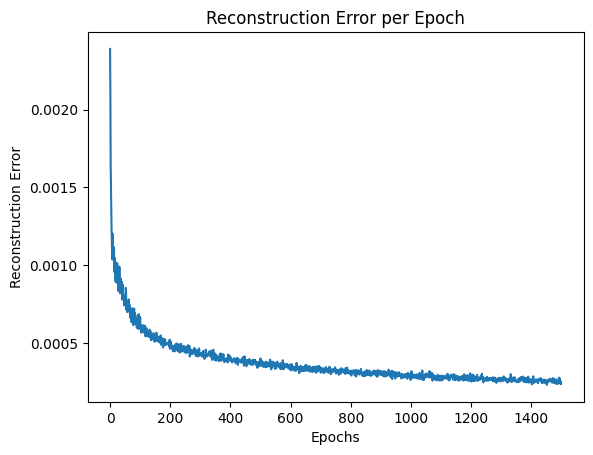

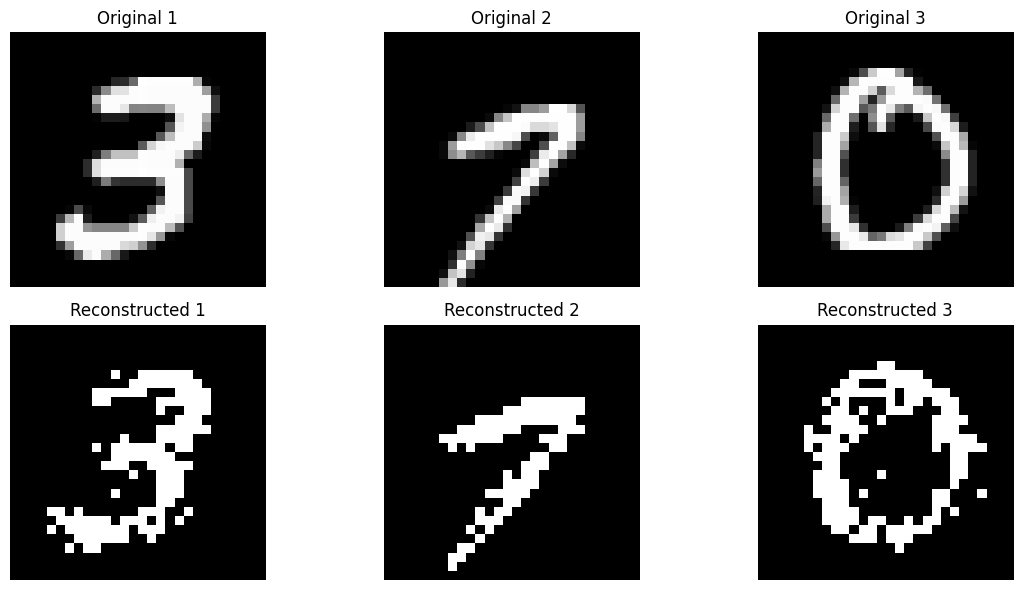

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        
        # Inicialización de los pesos y sesgos
        limit = np.sqrt(6 / (self.n_visible + self.n_hidden))
        self.weights = np.random.uniform(-limit, limit, (self.n_visible, self.n_hidden))
        self.bias_visible = np.zeros(n_visible)
        self.bias_hidden = np.zeros(n_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sample_hidden(self, v):
        # Paso de muestreo para la capa oculta
        hidden_activation = np.dot(v, self.weights) + self.bias_hidden
        hidden_prob = self.sigmoid(hidden_activation)
        hidden_state = (hidden_prob > np.random.rand(self.n_hidden)).astype(np.float64)
        return hidden_state, hidden_prob

    def sample_visible(self, h):
        # Paso de muestreo para la capa visible (sin agregar ruido)
        visible_activation = np.dot(h, self.weights.T) + self.bias_visible
        visible_prob = self.sigmoid(visible_activation)
        visible_state = (visible_prob > np.random.rand(self.n_visible)).astype(np.float64)
        return visible_state, visible_prob

    def contrastive_divergence(self, v0):
        # Paso de Gibbs (CD-1)
        h0, _ = self.sample_hidden(v0)  # Primer paso: calcular estado oculto
        vk, _ = self.sample_visible(h0)  # Reconstrucción del visible
        hk, _ = self.sample_hidden(vk)   # Estado oculto reconstruido

        return v0, h0, vk, hk

    def update_weights_and_biases(self, v0, h0, vk, hk):
        # Producto externo de las filas de visible_state con hidden_state
        positive_grad = np.dot(v0.T, h0)
        negative_grad = np.dot(vk.T, hk)

        # Actualización de los pesos
        self.weights += self.learning_rate * (positive_grad - negative_grad) / v0.shape[0]

        # Actualización de los sesgos
        self.bias_visible += self.learning_rate * np.mean(v0 - vk, axis=0)
        self.bias_hidden += self.learning_rate * np.mean(h0 - hk, axis=0)

    def train(self, train_data, epochs=10):
        errors = []  # Lista para almacenar los errores de cada época
        for epoch in range(epochs):
            total_error = 0  # Para calcular el error total de cada época

            # Contrastive Divergence (CD-1)
            v0, h0, vk, hk = self.contrastive_divergence(train_data)
            self.update_weights_and_biases(v0, h0, vk, hk)

            # Calcular el error de reconstrucción (error cuadrático medio)
            error = np.mean((train_data - vk) ** 2)  # Error cuadrático medio
            total_error += error

            # Guardar el error promedio de esta época
            errors.append(total_error / len(train_data))

        # Graficar el error de reconstrucción
        plt.plot(range(epochs), errors)
        plt.xlabel('Epochs')
        plt.ylabel('Reconstruction Error')
        plt.title('Reconstruction Error per Epoch')
        plt.show()

# Graficar 3 imágenes aleatorias de las originales y 3 de las reconstruidas
def plot_random_images(original_images, reconstructed_images, n_images=3):
    # Seleccionar 3 índices aleatorios
    random_indices = random.sample(range(original_images.shape[0]), n_images)

    plt.figure(figsize=(12, 6))

    # Graficar las imágenes originales
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, i)
        plt.imshow(original_images[idx].reshape(28, 28), cmap='gray')  # Asumo que las imágenes son 28x28
        plt.title(f'Original {i}')
        plt.axis('off')

    # Graficar las imágenes reconstruidas
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, n_images + i)
        plt.imshow(reconstructed_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Reconstructed {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Cargar el archivo .mat
mat_file_path = 'datosTrain.mat'
mat_data = scipy.io.loadmat(mat_file_path)

# Asignar los datos de entrenamiento y prueba desde el archivo .mat
train_images = mat_data['data'] 
# Normalizar las imágenes para que estén en el rango [0, 1]
train_images = train_images / 255.0

# Crear la RBM y entrenar
rbm_network = RBM(n_visible=784, n_hidden=100, learning_rate=0.1)  # Ajusta el número de neuronas ocultas y la tasa de aprendizaje
rbm_network.train(train_images, epochs=1500)  # Entrenamiento por 1500 épocas

# Obtener las imágenes reconstruidas
_, hidden_state = rbm_network.sample_hidden(train_images)
reconstructed_images, _ = rbm_network.sample_visible(hidden_state)

# Llamar a la función para graficar
plot_random_images(train_images, reconstructed_images)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random

class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.1):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        
        # Inicialización de los pesos y sesgos
        limit = np.sqrt(6 / (self.n_visible + self.n_hidden))
        self.weights = np.random.uniform(-limit, limit, (self.n_visible, self.n_hidden))
        self.bias_visible = np.zeros(n_visible)
        self.bias_hidden = np.zeros(n_hidden)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, input):
        # Forward pass sin binarización
        visible_state = np.random.normal(loc=input, scale=1, size=input.shape)
        hidden_activation = np.dot(visible_state, self.weights) + self.bias_hidden
        hidden_prob = self.sigmoid(hidden_activation)
        # Evitar la binarización aquí para preservar tonos intermedios
        hidden_state = hidden_prob  # Mantener las probabilidades
        return visible_state, hidden_state
    
    def backward(self, h):
        # Reconstrucción sin binarización
        m_i = np.dot(h, self.weights.T) + self.bias_visible
        visible_state = self.sigmoid(m_i)  # Usar sigmoide para mapear a [0, 1]
        return visible_state, h

    def update_weights_and_biases(self, v_o, h_o, v_k, h_k):
        positive_grad = np.dot(v_o.T, h_o)
        negative_grad = np.dot(v_k.T, h_k)

        # Actualización de los pesos
        self.weights += self.learning_rate * (positive_grad - negative_grad) / v_o.shape[0]

        # Actualización de los sesgos
        self.bias_visible += self.learning_rate * np.mean(v_o - v_k, axis=0)
        self.bias_hidden += self.learning_rate * np.mean(h_o - h_k, axis=0)

    def train(self, train_data, epochs=10):
        errors = []
        for epoch in range(epochs):
            total_error = 0
            visible_state, hidden_state = self.forward(train_data)
            visible_reconstructed, hidden_reconstructed = self.backward(hidden_state)
            self.update_weights_and_biases(visible_state, hidden_state, visible_reconstructed, hidden_reconstructed)

            # Error de reconstrucción
            error = np.mean((train_data - visible_reconstructed) ** 2)
            total_error += error
            errors.append(total_error / len(train_data))

        # Graficar el error de reconstrucción
        plt.plot(range(epochs), errors)
        plt.xlabel('Epochs')
        plt.ylabel('Reconstruction Error')
        plt.title('Reconstruction Error per Epoch')
        plt.show()


# Función para graficar
def plot_random_images(original_images, reconstructed_images, n_images=3):
    random_indices = random.sample(range(original_images.shape[0]), n_images)

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, i)
        plt.imshow(original_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Original {i}')
        plt.axis('off')

    for i, idx in enumerate(random_indices, 1):
        plt.subplot(2, n_images, n_images + i)
        plt.imshow(reconstructed_images[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Reconstructed {i}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Cargar el archivo .mat
mat_file_path = 'datosTrain.mat'
mat_data = scipy.io.loadmat(mat_file_path)

# Normalizar las imágenes entre 0 y 1
train_images = mat_data['data'] / 255.0

# Crear la RBM y entrenar
rbm_network = RBM(n_visible=784, n_hidden=50, learning_rate=0.001)
rbm_network.train(train_images, epochs=2500)

# Obtener las imágenes reconstruidas
_, hidden_state = rbm_network.forward(train_images)
reconstructed_images, _ = rbm_network.backward(hidden_state)

# Graficar las imágenes
plot_random_images(train_images, reconstructed_images)
